In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [24]:
df = pd.read_csv("/content/fmnist_small.csv")
df.head(10)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0
5,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,1,0,0,0,0,0,0,0,0,0,...,130,0,0,0,0,0,0,0,0,0
9,0,0,0,0,1,1,3,0,0,0,...,80,77,83,45,0,0,0,1,0,0


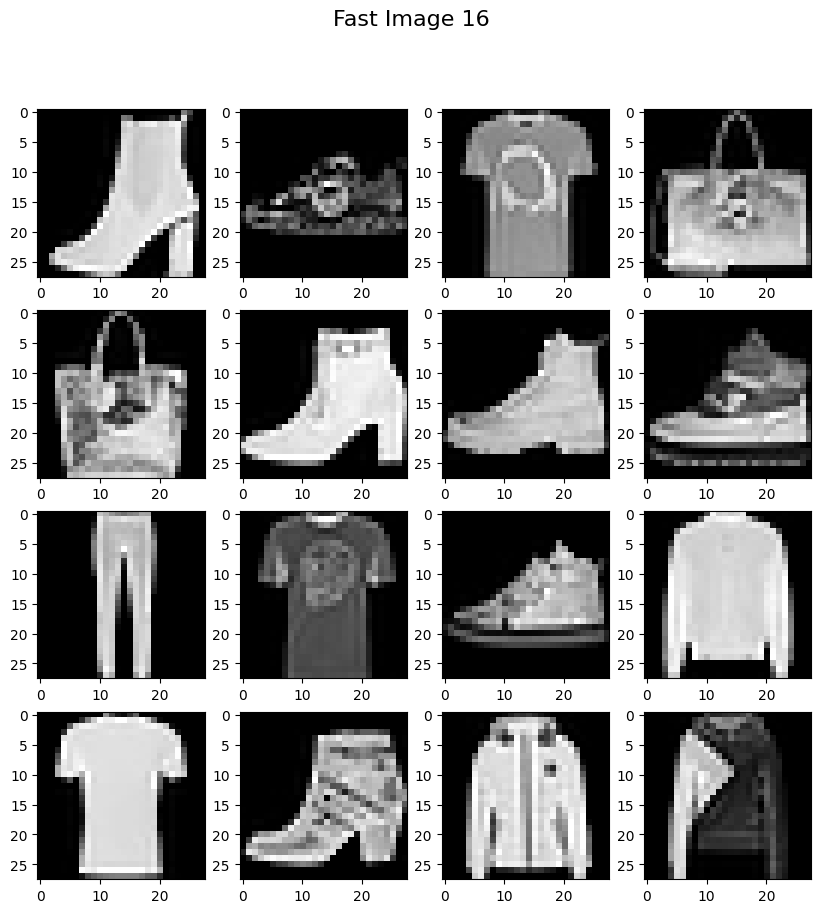

In [25]:
fig, axis = plt.subplots(4,4, figsize=(10,10))
fig.suptitle("Fast Image 16", fontsize=16)

for i , ax in enumerate(axis.flat):
  ax.imshow(np.array(df.iloc[i,1:]).reshape(28,28), cmap="gray")

In [26]:
X = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
X_train = X_train/255.0
X_test = X_test/255.0

In [29]:
class CustomDataset(Dataset):
  def __init__(self,  features, labals):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labals = torch.tensor(labals, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labals[index]

In [30]:
train_dataset  = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [31]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [32]:
len(train_dataset)

4800

In [33]:
class MyNN(nn.Module):
    def __init__(self, num_features):
        super(MyNN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

In [34]:
epochs = 10
learning_rate = 0.001

model = MyNN(X_train.shape[1])


In [40]:
criteion = nn.CrossEntropyLoss()
model.parameters()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [41]:
# Patching the model because 'forward' was defined inside __init__ in the class cell
model.forward = lambda x: model.model(x)

for epoch in range(epochs):
  total_epoch_loss = 0
  for batch_features, batch_label in train_loader:
    output = model(batch_features)

    loss = criteion(output, batch_label)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_epoch_loss += loss.item()

  avg_loss = total_epoch_loss / len(train_loader)
  print(avg_loss)

1.0034763981898627
0.6312728613615036
0.5445333806673686
0.4862232564886411
0.4499401745200157
0.42744595925013223
0.39723209430774054
0.3631644708911578
0.3516545293728511
0.31450747256477674


In [42]:
temp = torch.tensor([
    [0.2,0.1,0.1],
    [0.2,0.1,0.1]
])
_, pred = torch.max(temp, 1)
print(pred)

tensor([0, 0])


In [43]:
model.eval()
total = 0
correct = 0

with torch.no_grad():
  for batch_features, batch_label in test_loader:
    output = model(batch_features)
    _,pred = torch.max(output.data, 1)
    total += batch_label.size(0)
    correct += (pred == batch_label).sum().item()

print(correct/total)



0.8291666666666667


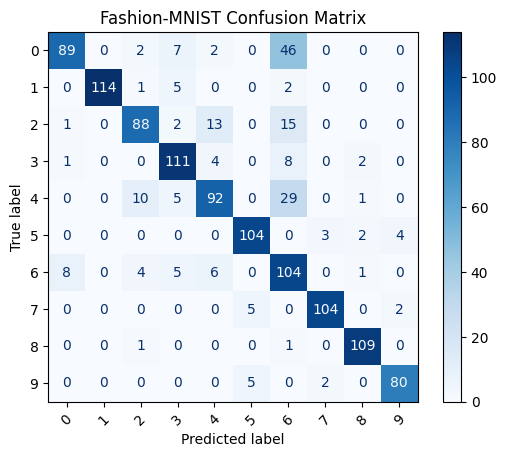

In [49]:

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_features, batch_label in test_loader:

        output = model(batch_features)

        _, pred = torch.max(output, 1)

        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(batch_label.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Fashion-MNIST Confusion Matrix")
plt.show()

In [50]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

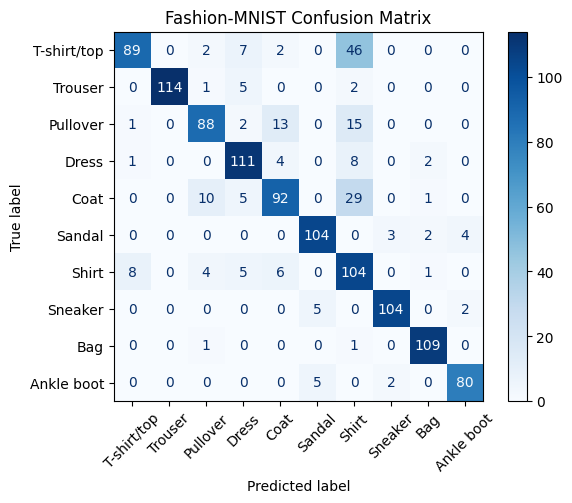

In [51]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Fashion-MNIST Confusion Matrix")
plt.show()